In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
df = pd.DataFrame({'T':[100,200,300,400,500,600],'B':[-160,-35,-4.2,9.0,16.9,21.3]})

In [6]:
df['B2'] = df['B']/100**3

In [7]:
df

,T,B,B2
0,100,-160.0,-0.000160
1,200,-35.0,-0.000035
2,300,-4.2,-0.000004
3,400,9.0,0.000009
4,500,16.9,0.000017
5,600,21.3,0.000021


In [13]:
df['n/V+'] = (-8.31*df['T'] + np.sqrt((8.31*df['T'])**2-4*df['B2']*8.31*df['T']*(-10**5)))/(2*df['B2']*8.31*df['T'])
#########################################################################################^ this parenthesis was missing

df['n/V-'] = (-8.31*df['T'] - np.sqrt((8.31*df['T'])**2-4*df['B2']*8.31*df['T']*(-10**5)))/(2*df['B2']*8.31*df['T'])

In [14]:
df

,T,B,B2,n/V+,n/V-,n/V ideal
0,100,-160.0,-0.000160,122.747662,6127.252338,120.336943
1,200,-35.0,-0.000035,60.295717,28511.132855,60.168472
2,300,-4.2,-0.000004,40.119075,238055.119021,40.112314
3,400,9.0,0.000009,30.076095,-111141.187206,30.084236
4,500,16.9,0.000017,24.057608,-59195.655241,24.067389
5,600,21.3,0.000021,20.047597,-46968.404404,20.056157


so to check this we should just evaluate the basic ideal gas law. it is easy to check which one is closer since this is supposed to be a small variation on that law.

$$ \frac{n}{V} = \frac{P}{R T}$$

In [15]:
df['n/V ideal'] = 10**5/8.31/df['T']

In [16]:
df

,T,B,B2,n/V+,n/V-,n/V ideal
0,100,-160.0,-0.000160,122.747662,6127.252338,120.336943
1,200,-35.0,-0.000035,60.295717,28511.132855,60.168472
2,300,-4.2,-0.000004,40.119075,238055.119021,40.112314
3,400,9.0,0.000009,30.076095,-111141.187206,30.084236
4,500,16.9,0.000017,24.057608,-59195.655241,24.067389
5,600,21.3,0.000021,20.047597,-46968.404404,20.056157


now we can see which one was closer, and not only that we can see how close it was! we should have just used the ideal gas law the whole time!!

In [17]:
df['n/V * B'] = df['B2']*df['n/V+']

In [18]:
df

,T,B,B2,n/V+,n/V-,n/V ideal,n/V * B
0,100,-160.0,-0.000160,122.747662,6127.252338,120.336943,-0.019640
1,200,-35.0,-0.000035,60.295717,28511.132855,60.168472,-0.002110
2,300,-4.2,-0.000004,40.119075,238055.119021,40.112314,-0.000169
3,400,9.0,0.000009,30.076095,-111141.187206,30.084236,0.000271
4,500,16.9,0.000017,24.057608,-59195.655241,24.067389,0.000407
5,600,21.3,0.000021,20.047597,-46968.404404,20.056157,0.000427


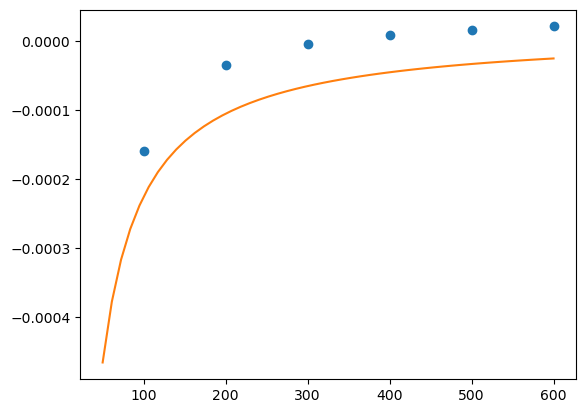

In [41]:
def Bee(a, b, T):
    return(b-a/8.31/T)

T = np.linspace(50,600)

    

fig0, ax0 = plt.subplots()
ax0.plot(df['T'], df['B2'], 'o')
ax0.plot(T, Bee(0.2, 0.000015, T))

# 